In [67]:
# Download latest version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Core tf.keras
from tensorflow.keras import layers, models, optimizers, applications
from tensorflow.keras import backend as K
from tensorflow.keras import Input, Model, Sequential

# Layers
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Input
)

# Optimizers
from tensorflow.keras.optimizers import Adam, SGD

# Callbacks
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    LearningRateScheduler,
    TensorBoard
)

In [68]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia


In [69]:
ACTUAL_DATASET_ROOT = path + "/chest_xray"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
TRAIN_DIR = ACTUAL_DATASET_ROOT + "/train"
VAL_DIR   = ACTUAL_DATASET_ROOT + "/val"
# TEST_DIR will also be needed later: ACTUAL_DATASET_ROOT + "/test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=123,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=123,
)
CLASS_NAMES = train_ds.class_names
CLASS_INDICES = {name: i for i, name in enumerate(CLASS_NAMES)}
rescale_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale_layer(x), y))
val_ds = val_ds.map(lambda x, y: (rescale_layer(x), y))

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.


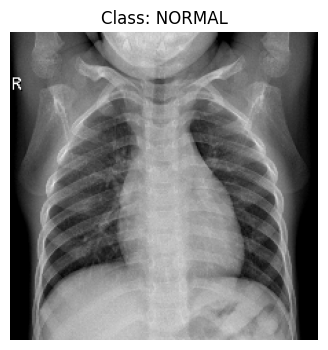

In [70]:
for images, labels in train_ds.take(1):
    img = images[0].numpy()
    label = int(labels[0])
    class_name = CLASS_NAMES[label]
    plt.figure(figsize=(4, 4))
    plt.imshow(img)  # pixels already in [0, 1] after rescaling
    plt.title(f"Class: {class_name}")
    plt.axis("off")
    plt.show()

In [71]:
# data_augmentation = tf.keras.Sequential([
#     layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.15),
#     layers.RandomZoom(0.2),
#     layers.RandomContrast(0.2),
# ])


In [72]:
model = models.Sequential([
    # data_augmentation,
    layers.Rescaling(1./255, input_shape=(224,224,3)),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_14 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [73]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
early_stop=EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=3,
    restore_best_weights=True
)
reduce_lr=ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=0.001
)

In [74]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop,reduce_lr]
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 22s 143ms/step - accuracy: 0.7193 - loss: 0.6055 - val_accuracy: 0.7766 - val_loss: 0.5620 - learning_rate: 0.0010
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 19s 144ms/step - accuracy: 0.7448 - loss: 0.5696 - val_accuracy: 0.7766 - val_loss: 0.3763 - learning_rate: 0.0010
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step - accuracy: 0.7895 - loss: 0.3301 - val_accuracy: 0.9348 - val_loss: 0.2303 - learning_rate: 0.0010
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 19s 145ms/step - accuracy: 0.9174 - loss: 0.2695 - val_accuracy: 0.9511 - val_loss: 0.2094 - learning_rate: 0.0010
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step - accuracy: 0.9404 - loss: 0.2337 - val_accuracy: 0.9223 - val_loss: 0.2147 - learning_rate: 0.0010
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step - accuracy: 0.9443 - loss: 0.2254 - val_accuracy: 0.9578 - val_loss: 0.1931 - learning_rate: 0.0010
Epoch 7/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step - accuracy: 0.9

In [75]:
# model.save("PRISM_MAIN_CNN_PIPELINE.h5")